# Fazer Importações 

In [4]:
# Biblioteca para as Operações numéricas
import numpy as np 

# Para Visualização
import matplotlib.pyplot as plt 

# Para redes neurais
import tensorflow as tf 

# Interface de alto nível para construir redes neurais
from tensorflow import keras

# Importando as camadas da rede
from tensorflow.keras.layers import Conv2D, Input, MaxPooling2D, Flatten, Dense, Dropout

# Funções utilitárias para trabalhar com imagens
from tensorflow.keras.utils import load_img, img_to_array




# Carregar a base de Dados CIFAR-10

In [5]:
# Carregar a base CIFAR-10
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Normalizar os valores para um intervalo [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# y vem como coluna. 
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = ['avião', 'automóvel', 'pássaro', 'gato', 'veado', 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

print(f'Formato do x_train: {x_train.shape}')
print(f'Formato do y_train: {y_train.shape}')
print(f'Formato do x_test: {x_test.shape}')
print(f'Formato do y_test: {y_test.shape}')


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
Formato do x_train: (50000, 32, 32, 3)
Formato do y_train: (50000,)
Formato do x_test: (10000, 32, 32, 3)
Formato do y_test: (10000,)


# Plotar algumas imagens

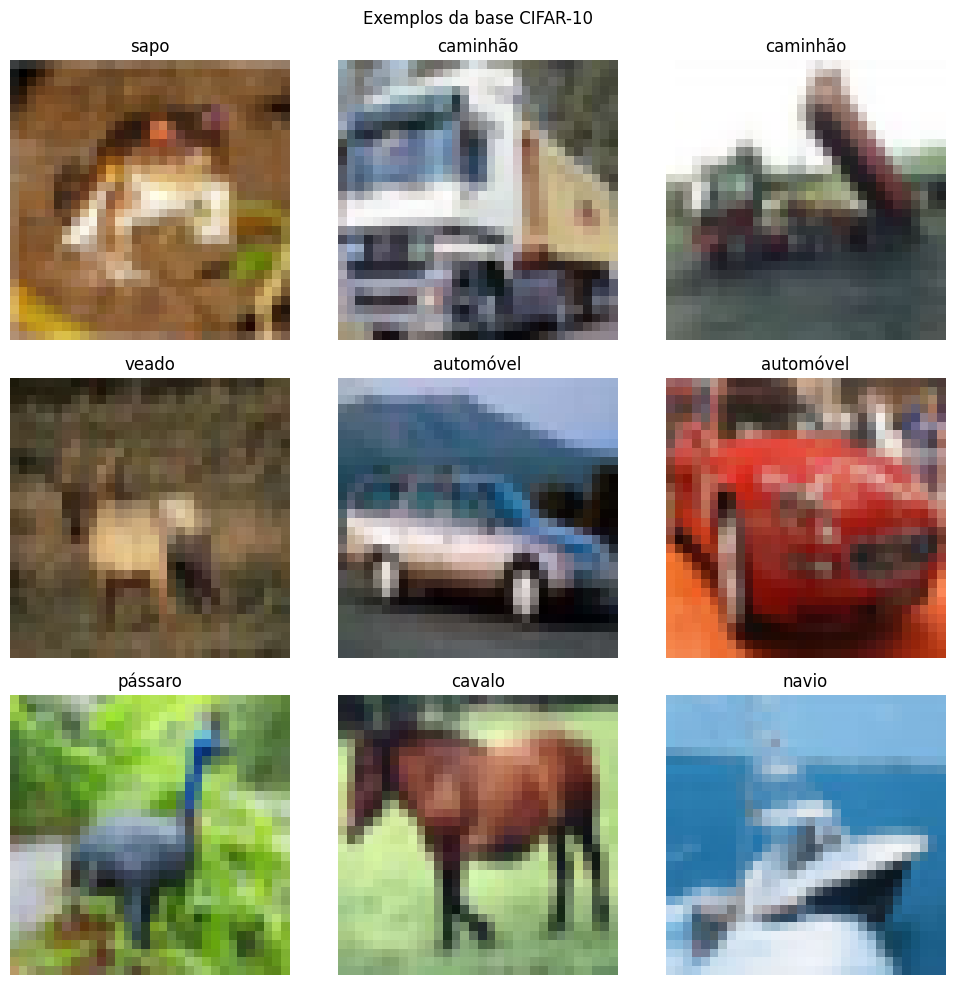

In [6]:
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle('Exemplos da base CIFAR-10')
plt.tight_layout()
plt.show()

# Criação do modelo CNN

In [7]:
model = keras.Sequential()

# Camada de entrada
model.add(Input(shape=(32, 32, 3)))

# Bloco 1
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 2
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Bloco 3
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Transição CNN => Dense (Totalmente Conectada)
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compilar o modelo
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Resumo da arquitetura do modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,682 (158.91 KB)

 Trainable params: 40,682 (158.91 KB)

 Non-trainable params: 0 (0.00 B)

# Treinar a rede

In [8]:
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 54ms/step - accuracy: 0.3798 - loss: 1.6958 - val_accuracy: 0.4649 - val_loss: 1.4904
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.5023 - loss: 1.3789 - val_accuracy: 0.5266 - val_loss: 1.3185
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.5534 - loss: 1.2543 - val_accuracy: 0.5583 - val_loss: 1.2393
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.5866 - loss: 1.1672 - val_accuracy: 0.5789 - val_loss: 1.1868
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.6151 - loss: 1.0964 - val_accuracy: 0.5974 - val_loss: 1.1490
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 49ms/step - accuracy: 0.6319 - loss: 1.0479 - val_accuracy: 0.6290 - val_loss: 1.0787
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.6543 - loss: 0.9924 - val_accuracy: 0.6289 - val_loss: 1.0754
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 40s 49ms/step - accuracy: 0.6653 - loss: 0.9592 - 

# Plot da acurácia e do loss

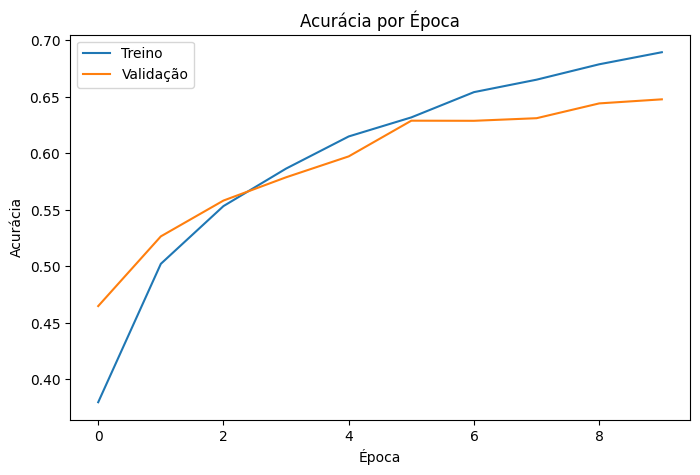

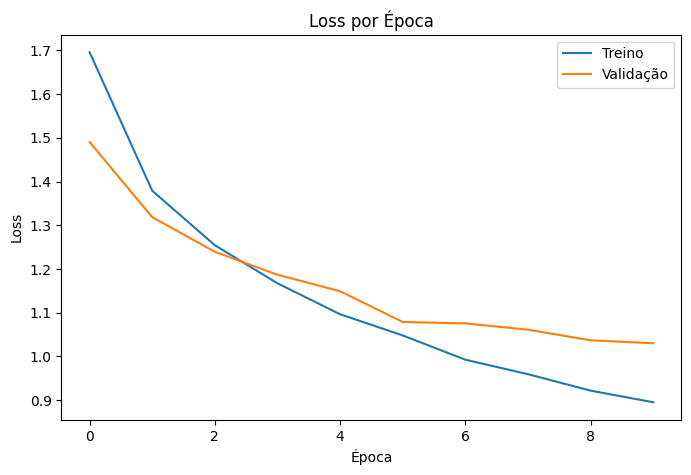

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia por Época')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss por Época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Realizando Avaliação

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print(f"Acurácia no conjunto de testes: {test_acc * 100:.2f}%")
print(f"Loss no conjunto de testes: {test_loss: .4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6405 - loss: 1.0359
Acurácia no conjunto de testes: 64.05%
Loss no conjunto de testes:  1.0359


# Previsões em imagens do teste

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


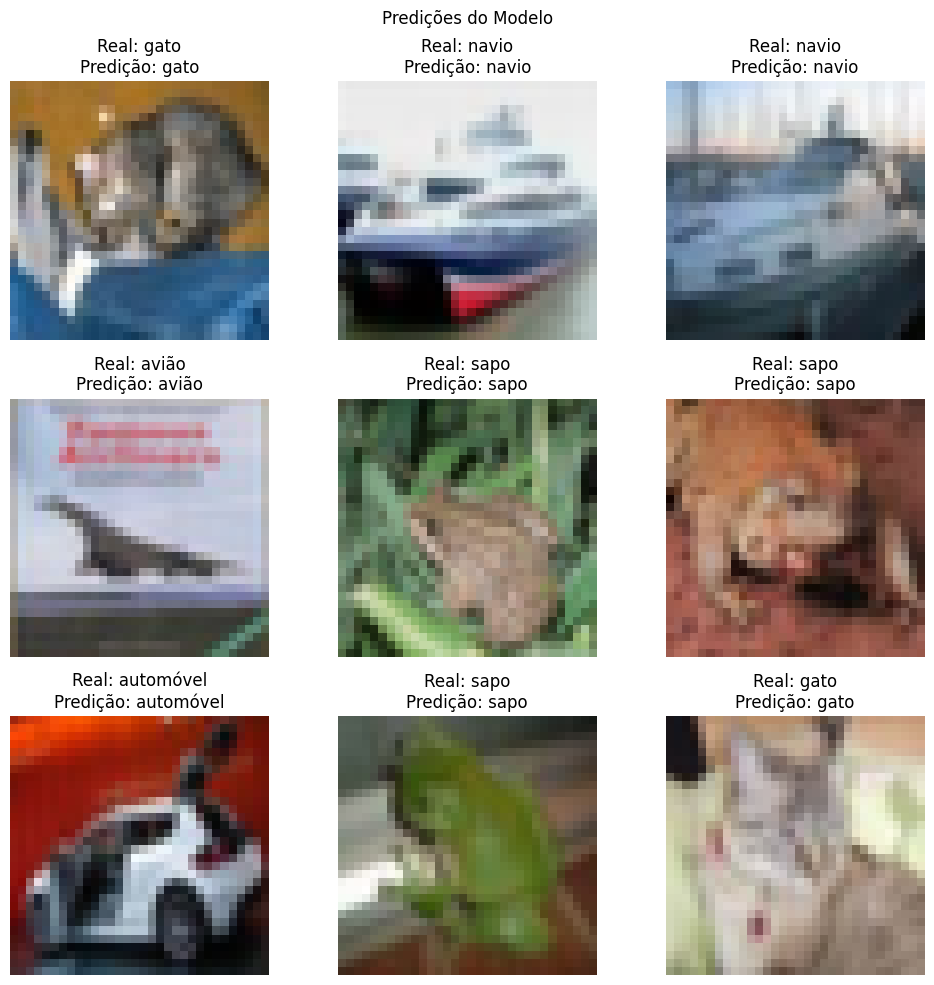

In [11]:
pred_probs = model.predict(x_test[:9])
pred_labels = np.argmax(pred_probs, axis=1)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i])
    real = class_names[y_test[i]]
    pred = class_names[pred_labels[i]]
    plt.title(f"Real: {real}\nPredição: {pred}")
    plt.axis('off')
plt.suptitle('Predições do Modelo')
plt.tight_layout()
plt.show()